In [1]:
# Cell 1: Imports & small helpers

import os
import csv
import math
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List
from collections import defaultdict, Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image

import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def device_string() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
# Cell 2: Metrics & plotting utilities

@torch.no_grad()
def confusion_matrix(preds: torch.Tensor, labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)
    for t, p in zip(labels.view(-1), preds.view(-1)):
        cm[t.long(), p.long()] += 1
    return cm

def per_class_prf1(cm: torch.Tensor) -> List[Dict[str, float]]:
    C = cm.size(0)
    res = []
    for c in range(C):
        tp = cm[c, c].item()
        fp = cm[:, c].sum().item() - tp
        fn = cm[c, :].sum().item() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        res.append({"precision": precision, "recall": recall, "f1": f1, "support": cm[c, :].sum().item()})
    return res

@torch.no_grad()
def compute_batch_metrics(logits: torch.Tensor, labels: torch.Tensor) -> Dict[str, float]:
    preds = logits.argmax(dim=1)
    correct = (preds == labels).sum().item()
    acc = correct / labels.size(0)
    num_classes = logits.size(1)
    cm = confusion_matrix(preds, labels, num_classes)
    stats = per_class_prf1(cm)
    macro_f1 = sum([x["f1"] for x in stats]) / num_classes if num_classes > 0 else 0.0
    return {"acc": acc, "macro_f1": macro_f1}

def plot_training_curves(history: Dict[str, List[float]]):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy curves")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_f1"], label="Train Macro-F1")
    plt.plot(epochs, history["val_f1"], label="Val Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title("Macro-F1 curves")
    plt.legend()
    plt.show()

def plot_confusion_matrix(cm: np.ndarray, class_names: List[str]):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix (rows=true, cols=pred)")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # annotate
    thresh = cm.max() / 2. if cm.size > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()


In [3]:
# Cell 3: Dataset & transforms (supports absolute image_path)

@dataclass
class DataConfig:
    img_dir: str           # can be "" if using absolute paths in CSV
    csv_path: str          # CSV with: image, Cancer status, Candidacy, image_path (optional)
    img_size: int = 224
    batch_size: int = 16
    num_workers: int = 0   # safer default in notebooks/Windows

def build_transforms(img_size: int) -> Tuple[transforms.Compose, transforms.Compose]:
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    return train_tf, eval_tf

class CSVImageDataset(Dataset):
    """
    CSV headers required:
      image, Cancer status, Candidacy
    Optional:
      image_path (absolute path). If present, it is preferred over img_dir + image.
    """
    def __init__(self,
                 img_dir: str,
                 csv_path: str,
                 transform: Optional[transforms.Compose] = None,
                 image_col: str = "image",
                 path_col: str = "image_path",
                 label_col: str = "Cancer status",
                 candidacy_col: str = "Candidacy"):
        self.img_dir = img_dir
        self.transform = transform
        self.image_col = image_col
        self.path_col = path_col
        self.label_col = label_col
        self.candidacy_col = candidacy_col

        self.samples: List[Dict] = []
        with open(csv_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            required = {image_col, label_col, candidacy_col}
            missing = required - set(reader.fieldnames or [])
            if missing:
                raise ValueError(f"CSV {csv_path} missing columns: {missing}")

            for row in reader:
                fname = row[image_col].strip()
                label = int(row[label_col])
                cand = row.get(candidacy_col, "").strip()
                cand_int = int(cand) if cand != "" else -1

                # absolute path if provided
                abs_path = row.get(self.path_col, "").strip()
                if abs_path:
                    full = abs_path
                else:
                    full = os.path.join(img_dir, fname)

                self.samples.append({
                    "path": full,
                    "label": label,
                    "candidacy": cand_int,
                    "fname": fname
                })

        if len(self.samples) == 0:
            raise RuntimeError(f"No rows loaded from {csv_path}. Check paths/CSV.")

        missing_files = [s["path"] for s in self.samples if not os.path.isfile(s["path"])]
        if missing_files:
            preview = ", ".join(missing_files[:5])
            raise FileNotFoundError(
                f"{len(missing_files)} images in CSV not found. First few: {preview}"
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        sample = self.samples[idx]
        img = Image.open(sample["path"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = sample["label"]
        return img, label


In [12]:
# === NEW CELL: Auto-crop flashcard photos and rewrite CSVs to use cropped images ===
# Requires: opencv-python
# If needed:  !pip install opencv-python

import os, csv, shutil
from pathlib import Path
import numpy as np
import cv2

def detect_main_photo_bbox(img_bgr, thr=200):
    """
    Heuristic: on a white flashcard, the embedded photo is the largest
    dark-ish blob. We threshold (binary INV) and take the largest contour.
    Returns (x, y, w, h). Falls back to a conservative center crop if needed.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, thr, 255, cv2.THRESH_BINARY_INV)

    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(cnts) == 0:
        # fallback: center box (70% width, 50% height)
        H, W = gray.shape[:2]
        w, h = int(W * 0.7), int(H * 0.5)
        x, y = (W - w) // 2, int(H * 0.22)
        return (x, y, w, h)

    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)
    x, y, w, h = cv2.boundingRect(cnts[0])

    # safety clamp & small padding
    H, W = gray.shape[:2]
    pad = max(2, int(0.01 * max(W, H)))
    x = max(0, x - pad); y = max(0, y - pad)
    w = min(W - x, w + 2 * pad)
    h = min(H - y, h + 2 * pad)

    return (x, y, w, h)

def crop_image_file(src_path: str, dst_path: str):
    img = cv2.imread(str(src_path))
    if img is None:
        raise FileNotFoundError(f"Could not read image: {src_path}")
    x, y, w, h = detect_main_photo_bbox(img)
    crop = img[y:y+h, x:x+w]
    Path(dst_path).parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(dst_path), crop)

def rewrite_csv_to_cropped(csv_in: str, img_root: str, out_img_root: str, csv_out: str,
                           keep_name_suffix="_crop"):
    """
    Reads a tags CSV with columns: image, Cancer status, Candidacy (plus optional image_path),
    crops each image from img_root, writes cropped image to out_img_root, and writes a new CSV
    with updated image filename and absolute image_path pointing to the cropped file.
    """
    img_root = Path(img_root)
    out_img_root = Path(out_img_root)
    out_img_root.mkdir(parents=True, exist_ok=True)

    rows_out = []
    with open(csv_in, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if "image" not in reader.fieldnames:
            raise ValueError(f"{csv_in} must have an 'image' column")

        for r in reader:
            r = dict(r)
            fname = r["image"].strip()
            src_path = img_root / fname

            stem = Path(fname).stem
            ext  = Path(fname).suffix or ".jpg"
            new_name = stem + keep_name_suffix + ext
            dst_path = out_img_root / new_name

            crop_image_file(src_path, dst_path)

            # update CSV row
            r["image"] = new_name
            r["image_path"] = str(dst_path.resolve())
            rows_out.append(r)

    headers = list(rows_out[0].keys()) if rows_out else ["image", "Cancer status", "Candidacy", "image_path"]
    with open(csv_out, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=headers)
        w.writeheader()
        w.writerows(rows_out)

    print(f"✔ Wrote cropped CSV: {csv_out}")
    print(f"  Images in: {out_img_root}")

# ---------- USAGE ----------
# 1) Point these to your *original* (uncropped) image roots + CSVs:
train_img_dir_src = r"G:\Jhpiego_data.v1i.coco\train"
val_img_dir_src   = r"G:\Jhpiego_data.v1i.coco\valid"
test_img_dir_src  = r"G:\Jhpiego_data.v1i.coco\test"

train_csv_src = r"G:\Jhpiego_data.v1i.coco\train\_tags.csv"
val_csv_src   = r"G:\Jhpiego_data.v1i.coco\valid\_tags.csv"
test_csv_src  = r"G:\Jhpiego_data.v1i.coco\test\_tags.csv"

# 2) Choose where to store cropped images + new CSVs:
cropped_root = Path("CROPPED_FLASHCARDS")
(train_out_img, val_out_img, test_out_img) = (
    cropped_root / "train_images", cropped_root / "val_images", cropped_root / "test_images"
)
(train_out_csv, val_out_csv, test_out_csv) = (
    cropped_root / "train_tags.csv", cropped_root / "val_tags.csv", cropped_root / "test_tags.csv"
)

# 3) Run cropping + CSV rewrite (one-time per dataset version):
rewrite_csv_to_cropped(train_csv_src, train_img_dir_src, str(train_out_img), str(train_out_csv))
rewrite_csv_to_cropped(val_csv_src,   val_img_dir_src,   str(val_out_img),   str(val_out_csv))
rewrite_csv_to_cropped(test_csv_src,  test_img_dir_src,  str(test_out_img),  str(test_out_csv))

print("\nNow point the downstream cells to these CROPPED paths/CSVs.")
print(f"Train: img_dir={train_out_img}  csv={train_out_csv}")
print(f"Val  : img_dir={val_out_img}    csv={val_out_csv}")
print(f"Test : img_dir={test_out_img}   csv={test_out_csv}")


✔ Wrote cropped CSV: CROPPED_FLASHCARDS\train_tags.csv
  Images in: CROPPED_FLASHCARDS\train_images
✔ Wrote cropped CSV: CROPPED_FLASHCARDS\val_tags.csv
  Images in: CROPPED_FLASHCARDS\val_images
✔ Wrote cropped CSV: CROPPED_FLASHCARDS\test_tags.csv
  Images in: CROPPED_FLASHCARDS\test_images

Now point the downstream cells to these CROPPED paths/CSVs.
Train: img_dir=CROPPED_FLASHCARDS\train_images  csv=CROPPED_FLASHCARDS\train_tags.csv
Val  : img_dir=CROPPED_FLASHCARDS\val_images    csv=CROPPED_FLASHCARDS\val_tags.csv
Test : img_dir=CROPPED_FLASHCARDS\test_images   csv=CROPPED_FLASHCARDS\test_tags.csv


In [13]:
# Cell 4: Combine three CSVs, then stratify into new train/val/test ensuring test has Cancerous

set_seed(42)

#  -----NEW PATHS------
train_img_dir_src = str(Path("CROPPED_FLASHCARDS") / "train_images")
val_img_dir_src   = str(Path("CROPPED_FLASHCARDS") / "val_images")
test_img_dir_src  = str(Path("CROPPED_FLASHCARDS") / "test_images")

train_csv_src = str(Path("CROPPED_FLASHCARDS") / "train_tags.csv")
val_csv_src   = str(Path("CROPPED_FLASHCARDS") / "val_tags.csv")
test_csv_src  = str(Path("CROPPED_FLASHCARDS") / "test_tags.csv")


# output dir for the new stratified CSVs
out_dir = Path("STRAT_SPLIT")
out_dir.mkdir(parents=True, exist_ok=True)
train_csv_new = str(out_dir / "train_tags.csv")
val_csv_new   = str(out_dir / "val_tags.csv")
test_csv_new  = str(out_dir / "test_tags.csv")

# desired split ratios
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

# --- Load & combine three CSVs, attach absolute image_path ---
def load_rows(csv_path, img_root):
    """
    Loads rows from a Roboflow-style tags CSV and attaches absolute image_path.
    - Cancer status: accepts {0,1,2} or strings {"Normal","Pre-cancerous","Cancerous"}
    - Candidacy: accepts {0,1,''} or strings {"Bad-candidate","Good-candidate"} (case-insensitive)
                 Missing/empty -> -1
    """
    # helpers
    def parse_cancer_status(v):
        s = str(v).strip()
        mapping = {
            "normal": 0,
            "pre-cancerous": 1,
            "precancerous": 1,
            "cancerous": 2,
        }
        if s.lower() in mapping:
            return mapping[s.lower()]
        return int(s)  # will raise if it's truly invalid

    def parse_candidacy(v):
        s = ("" if v is None else str(v)).strip()
        if s == "":           # empty -> unknown
            return -1
        m = {
            "0": 0, "bad": 0, "bad-candidate": 0,
            "1": 1, "good": 1, "good-candidate": 1,
        }
        return m.get(s.lower(), -1)  # unknown/malformed -> -1

    rows = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            r = dict(r)

            # normalize fields
            cancer_int   = parse_cancer_status(r.get("Cancer status", ""))
            candidacy_int = parse_candidacy(r.get("Candidacy", ""))

            # attach absolute path
            fname = r["image"].strip()
            r_norm = {
                "image": fname,
                "Cancer status": str(cancer_int),
                "Candidacy": str(candidacy_int),
                "image_path": str(Path(img_root) / fname),
            }
            rows.append(r_norm)
    return rows


rows_all = []
rows_all += load_rows(train_csv_src, train_img_dir_src)
rows_all += load_rows(val_csv_src,   val_img_dir_src)
rows_all += load_rows(test_csv_src,  test_img_dir_src)

print(f"Total rows combined: {len(rows_all)}")

# --- Group by class for stratification ---
by_class = defaultdict(list)
for r in rows_all:
    c = int(r["Cancer status"])
    by_class[c].append(r)

print("Combined class counts:", {k: len(v) for k, v in sorted(by_class.items())})

# --- Stratify into train/val/test, ensuring test has >=1 Cancerous if available ---
def stratified_split(by_class: Dict[int, List[dict]],
                     train_ratio: float, val_ratio: float, test_ratio: float,
                     min_in_test: Dict[int, int]):

    train_rows, val_rows, test_rows = [], [], []

    for k in sorted(by_class.keys()):
        items = by_class[k][:]
        random.shuffle(items)
        n = len(items)
        # first allocate minimum required to test (if class exists)
        need_test = min_in_test.get(k, 0)
        n_test = min(need_test, n)
        test_rows += items[:n_test]
        rem = items[n_test:]

        # split remainder by ratios
        n_rem = len(rem)
        n_train = max(0, int(round(train_ratio * n_rem)))
        n_val   = max(0, int(round(val_ratio   * n_rem)))
        # ensure totals match
        while n_train + n_val > n_rem:
            if n_val > 0: n_val -= 1
            elif n_train > 0: n_train -= 1
            else: break
        n_test_extra = n_rem - (n_train + n_val)

        train_rows += rem[:n_train]
        val_rows   += rem[n_train:n_train+n_val]
        test_rows  += rem[n_train+n_val:n_train+n_val+n_test_extra]

    return train_rows, val_rows, test_rows

# enforce at least 1 Cancerous in test if available
min_in_test = {0: 0, 1: 0, 2: 1}
train_rows, val_rows, test_rows = stratified_split(by_class, train_ratio, val_ratio, test_ratio, min_in_test)

def write_csv(path, rows):
    headers = ["image", "Cancer status", "Candidacy", "image_path"]
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=headers)
        w.writeheader()
        for r in rows:
            w.writerow({
                "image": r["image"],
                "Cancer status": r["Cancer status"],
                "Candidacy": r["Candidacy"],
                "image_path": r["image_path"],
            })

write_csv(train_csv_new, train_rows)
write_csv(val_csv_new,   val_rows)
write_csv(test_csv_new,  test_rows)

def counts_from_csv(csv_path):
    c = Counter()
    with open(csv_path, "r", encoding="utf-8") as f:
        for r in csv.DictReader(f):
            c[int(r["Cancer status"])] += 1
    return dict(sorted(c.items()))

print("NEW TRAIN:", counts_from_csv(train_csv_new))
print("NEW VAL  :", counts_from_csv(val_csv_new))
print("NEW TEST :", counts_from_csv(test_csv_new))

# paths we will actually use for training below (img_dir can be empty because image_path is absolute)
final_train_img_dir = ""
final_val_img_dir   = ""
final_test_img_dir  = ""

final_train_csv = train_csv_new
final_val_csv   = val_csv_new
final_test_csv  = test_csv_new


Total rows combined: 275
Combined class counts: {0: 135, 1: 127, 2: 13}
NEW TRAIN: {0: 94, 1: 89, 2: 8}
NEW VAL  : {0: 20, 1: 19, 2: 2}
NEW TEST : {0: 21, 1: 19, 2: 3}


In [14]:
# Cell 5: Build loaders & class weights (same as before)

def class_counts_from_csv(csv_path: str, label_col: str = "Cancer status", num_classes: int = 3):
    counts = [0] * num_classes
    with open(csv_path, "r", encoding="utf-8") as f:
        for r in csv.DictReader(f):
            y = int(r[label_col])
            if 0 <= y < num_classes:
                counts[y] += 1
    return counts

def make_class_weights(counts: List[int]) -> torch.Tensor:
    total = sum(counts)
    weights = [ (total / c) if c > 0 else 0.0 for c in counts ]
    return torch.tensor(weights, dtype=torch.float)

def build_loaders_from_csv(
    train_cfg: DataConfig,
    val_cfg: DataConfig,
    test_cfg: Optional[DataConfig] = None,
    use_weighted_sampler: bool = True
):
    train_tf, eval_tf = build_transforms(train_cfg.img_size)

    train_ds = CSVImageDataset(train_cfg.img_dir, train_cfg.csv_path, transform=train_tf)
    val_ds   = CSVImageDataset(val_cfg.img_dir,   val_cfg.csv_path,   transform=eval_tf)
    test_ds  = CSVImageDataset(test_cfg.img_dir,  test_cfg.csv_path,  transform=eval_tf) \
               if (test_cfg and os.path.isfile(test_cfg.csv_path)) else None

    idx_to_class = {0: "Normal", 1: "Pre-cancerous", 2: "Cancerous"}
    print("Class mapping:", idx_to_class)

    counts = class_counts_from_csv(train_cfg.csv_path, label_col="Cancer status", num_classes=3)
    print("Train class counts:", counts)
    class_weights = make_class_weights(counts)
    print("Class weights (CE):", class_weights.tolist())

    pin = torch.cuda.is_available()

    if use_weighted_sampler:
        per_sample_weights = [class_weights[s["label"]].item() for s in train_ds.samples]
        sampler = WeightedRandomSampler(
            weights=per_sample_weights,
            num_samples=len(per_sample_weights),
            replacement=True
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=train_cfg.batch_size,
            sampler=sampler,
            num_workers=train_cfg.num_workers,
            pin_memory=pin,
            persistent_workers=False,
        )
    else:
        train_loader = DataLoader(
            train_ds,
            batch_size=train_cfg.batch_size,
            shuffle=True,
            num_workers=train_cfg.num_workers,
            pin_memory=pin,
            persistent_workers=False,
        )

    val_loader = DataLoader(
        val_ds,
        batch_size=val_cfg.batch_size,
        shuffle=False,
        num_workers=val_cfg.num_workers,
        pin_memory=pin,
        persistent_workers=False,
    )
    test_loader = None
    if test_ds is not None:
        test_loader = DataLoader(
            test_ds,
            batch_size=test_cfg.batch_size,
            shuffle=False,
            num_workers=test_cfg.num_workers,
            pin_memory=pin,
            persistent_workers=False,
        )

    return train_loader, val_loader, test_loader, idx_to_class, class_weights


In [15]:
# Cell 6: Models (same as before)

def build_vgg16(num_classes: int = 3, fine_tune: bool = True) -> nn.Module:
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for p in model.features.parameters():
        p.requires_grad = fine_tune
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model

def build_resnet18(num_classes: int = 3, fine_tune: bool = True) -> nn.Module:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = fine_tune
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


In [16]:
# Cell 7: Evaluate & Train (returns history for plotting)

@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=3):
    model.eval()
    total_loss = total_acc = total_f1 = total_n = 0
    agg_cm = torch.zeros((num_classes, num_classes), dtype=torch.long)
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)

        metrics = compute_batch_metrics(logits, y)
        preds = logits.argmax(dim=1)
        cm = confusion_matrix(preds, y, num_classes)
        agg_cm += cm

        bsz = y.size(0)
        total_loss += loss.item() * bsz
        total_acc  += metrics["acc"] * bsz
        total_f1   += metrics["macro_f1"] * bsz
        total_n    += bsz

    avg = {
        "loss": total_loss / max(total_n, 1),
        "acc":  total_acc  / max(total_n, 1),
        "macro_f1": total_f1 / max(total_n, 1),
        "cm": agg_cm
    }
    return avg

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    patience=3,
    num_classes=3
):
    best_val_f1 = -1.0
    best_state = None
    bad_epochs = 0

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_f1": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = total_acc = total_f1 = total_n = 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            m = compute_batch_metrics(logits, y)
            bsz = y.size(0)
            total_loss += loss.item() * bsz
            total_acc  += m["acc"] * bsz
            total_f1   += m["macro_f1"] * bsz
            total_n    += bsz

        train_stats = {
            "loss": total_loss / max(total_n, 1),
            "acc":  total_acc  / max(total_n, 1),
            "macro_f1": total_f1 / max(total_n, 1),
        }
        val_stats = evaluate(model, val_loader, criterion, device, num_classes=num_classes)

        history["train_loss"].append(train_stats["loss"])
        history["train_acc"].append(train_stats["acc"])
        history["train_f1"].append(train_stats["macro_f1"])
        history["val_loss"].append(val_stats["loss"])
        history["val_acc"].append(val_stats["acc"])
        history["val_f1"].append(val_stats["macro_f1"])

        print(f"[Epoch {epoch:02d}] "
              f"Train loss={train_stats['loss']:.4f} acc={train_stats['acc']:.4f} F1={train_stats['macro_f1']:.4f} | "
              f"Val loss={val_stats['loss']:.4f} acc={val_stats['acc']:.4f} F1={val_stats['macro_f1']:.4f}")

        if val_stats["macro_f1"] > best_val_f1 + 1e-6:
            best_val_f1 = val_stats["macro_f1"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch} (no val F1 improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {"best_val_macro_f1": best_val_f1, "history": history}


Using device: cpu
Class mapping: {0: 'Normal', 1: 'Pre-cancerous', 2: 'Cancerous'}
Train class counts: [94, 89, 8]
Class weights (CE): [2.0319149494171143, 2.1460673809051514, 23.875]

=== Stage 1 Training ===
[Epoch 01] Train loss=1.3176 acc=0.5340 F1=0.3594 | Val loss=1.0822 acc=0.7317 F1=0.4221
[Epoch 02] Train loss=1.0214 acc=0.6911 F1=0.5154 | Val loss=1.0165 acc=0.6341 F1=0.3202
[Epoch 03] Train loss=0.9019 acc=0.7120 F1=0.5613 | Val loss=0.9420 acc=0.7317 F1=0.3800
[Epoch 04] Train loss=0.7554 acc=0.8010 F1=0.6714 | Val loss=0.8225 acc=0.8780 F1=0.4679
[Epoch 05] Train loss=0.7345 acc=0.8325 F1=0.6950 | Val loss=0.7895 acc=0.9024 F1=0.4803
[Epoch 06] Train loss=0.6303 acc=0.8429 F1=0.7246 | Val loss=0.7808 acc=0.9268 F1=0.4883
[Epoch 07] Train loss=0.6853 acc=0.8953 F1=0.7177 | Val loss=0.8365 acc=0.8049 F1=0.4389
[Epoch 08] Train loss=0.6180 acc=0.9215 F1=0.7978 | Val loss=0.7845 acc=0.8537 F1=0.4717
Best Val Macro-F1 (Stage 1): 0.4883


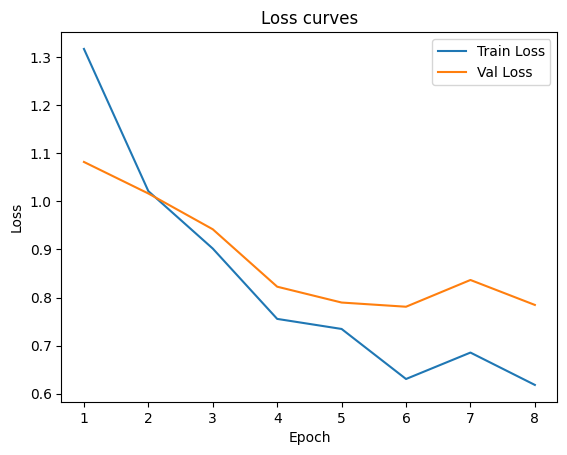

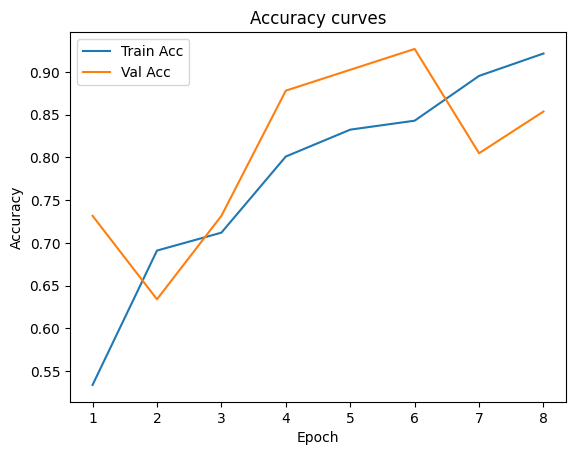

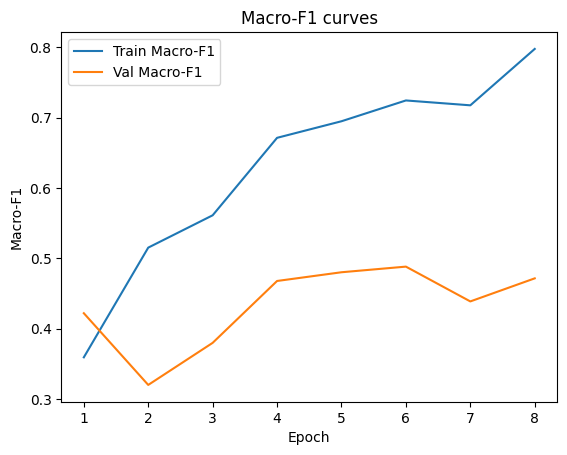

Saved model to: C:\Users\niran\OneDrive\Desktop\pre-trained model\checkpoints\vgg16_best.pt


In [ ]:
# Cell 8: Configure, build loaders, train (Stage 1) + PLOTS

set_seed(42)
dev = device_string()
print("Using device:", dev)

# Use the newly created combined/stratified CSVs & empty img_dir (we rely on absolute image_path)
IMG_SIZE   = 224
BATCH      = 16
EPOCHS     = 8
WORKERS    = 0
LR         = 1e-4
WD         = 1e-4
FREEZE_BACKBONE = True
USE_RESNET18    = False
USE_WEIGHTED_SAMPLER = True
LABEL_SMOOTH    = 0.05
PATIENCE        = 3

train_cfg = DataConfig(img_dir=final_train_img_dir, csv_path=final_train_csv,
                       img_size=IMG_SIZE, batch_size=BATCH, num_workers=WORKERS)
val_cfg   = DataConfig(img_dir=final_val_img_dir,   csv_path=final_val_csv,
                       img_size=IMG_SIZE, batch_size=BATCH, num_workers=WORKERS)
test_cfg  = DataConfig(img_dir=final_test_img_dir,  csv_path=final_test_csv,
                       img_size=IMG_SIZE, batch_size=BATCH, num_workers=WORKERS)

train_loader, val_loader, test_loader, idx_to_class, class_weights = build_loaders_from_csv(
    train_cfg, val_cfg, test_cfg, use_weighted_sampler=USE_WEIGHTED_SAMPLER
)

# Build model
if USE_RESNET18:
    model = build_resnet18(num_classes=3, fine_tune=(not FREEZE_BACKBONE)).to(dev)
else:
    model = build_vgg16(num_classes=3, fine_tune=(not FREEZE_BACKBONE)).to(dev)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights.to(dev) if class_weights is not None else None,
                                label_smoothing=LABEL_SMOOTH)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=LR, weight_decay=WD)

print("\n=== Stage 1 Training ===")
result = train_model(model, train_loader, val_loader, criterion, optimizer, dev,
                     epochs=EPOCHS, patience=PATIENCE, num_classes=3)

print(f"Best Val Macro-F1 (Stage 1): {result['best_val_macro_f1']:.4f}")

# PLOTS: training curves
plot_training_curves(result["history"])

# Save checkpoint
ckpt_dir = Path("checkpoints"); ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / ("resnet18_best.pt" if USE_RESNET18 else "vgg16_best.pt")
torch.save(model.state_dict(), ckpt_path)
print("Saved model to:", ckpt_path.resolve())



=== Stage 2 Fine-tuning (unfrozen) ===
[Epoch 01] Train loss=0.7516 acc=0.7696 F1=0.6515 | Val loss=0.8339 acc=0.8780 F1=0.4810
[Epoch 02] Train loss=0.6002 acc=0.9372 F1=0.8137 | Val loss=0.6897 acc=0.8537 F1=0.4548
[Epoch 03] Train loss=0.5435 acc=0.9581 F1=0.8222 | Val loss=0.6612 acc=0.9024 F1=0.4819
[Epoch 04] Train loss=0.5240 acc=0.9738 F1=0.8357 | Val loss=0.6776 acc=0.8780 F1=0.4788
[Epoch 05] Train loss=0.5149 acc=0.9843 F1=0.8142 | Val loss=0.6486 acc=0.9024 F1=0.4964
Best Val Macro-F1 (Stage 2): 0.4964


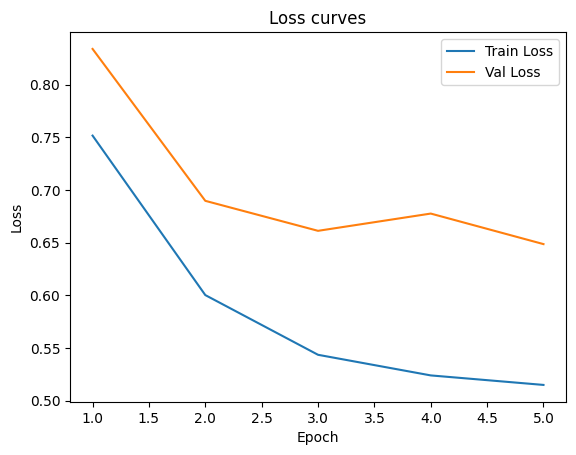

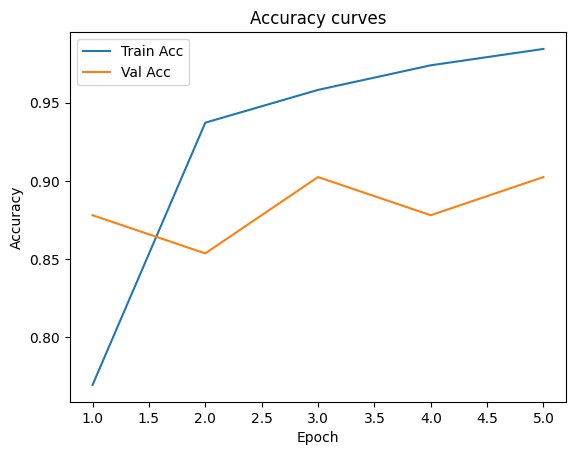

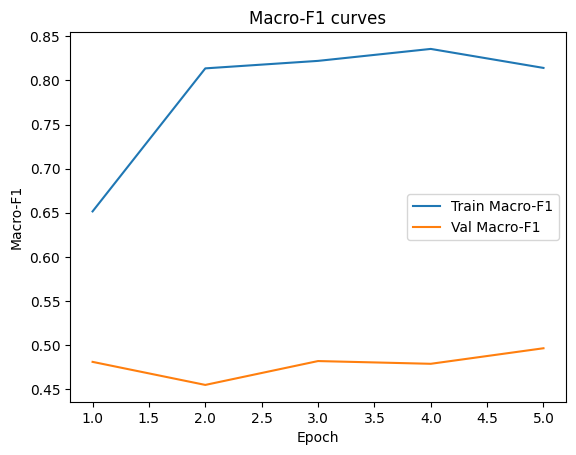

Saved fine-tuned model to: C:\Users\niran\OneDrive\Desktop\pre-trained model\checkpoints\vgg16_finetuned.pt


In [22]:
# Cell 9: Optional Stage 2 (unfreeze & fine-tune) + PLOTS

UNFREEZE_AND_FINETUNE = True
FINETUNE_EPOCHS = 5
FINETUNE_LR     = 5e-5
FINETUNE_WD     = 1e-4

if UNFREEZE_AND_FINETUNE:
    for p in model.parameters():
        p.requires_grad = True

    optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=FINETUNE_WD)
    print("\n=== Stage 2 Fine-tuning (unfrozen) ===")
    result2 = train_model(model, train_loader, val_loader, criterion, optimizer, dev,
                          epochs=FINETUNE_EPOCHS, patience=PATIENCE, num_classes=3)
    print(f"Best Val Macro-F1 (Stage 2): {result2['best_val_macro_f1']:.4f}")

    # PLOTS: training curves for stage 2
    plot_training_curves(result2["history"])

    ckpt_path2 = Path("checkpoints") / ("resnet18_finetuned.pt" if USE_RESNET18 else "vgg16_finetuned.pt")
    torch.save(model.state_dict(), ckpt_path2)
    print("Saved fine-tuned model to:", ckpt_path2.resolve())
else:
    print("Skipping Stage 2 fine-tuning.")



=== Test Results ===
Loss: 0.6896  Acc: 0.8837  Macro-F1: 0.4899

Per-class metrics:
  0 (Normal): precision=0.808  recall=1.000  f1=0.894  sensitivity=1.000  specificity=0.773  support=21
  1 (Pre-cancerous): precision=1.000  recall=0.737  f1=0.848  sensitivity=0.737  specificity=1.000  support=19
  2 (Cancerous): precision=1.000  recall=1.000  f1=1.000  sensitivity=1.000  specificity=1.000  support=3

Macro-avg Sensitivity: 0.912  Specificity: 0.924


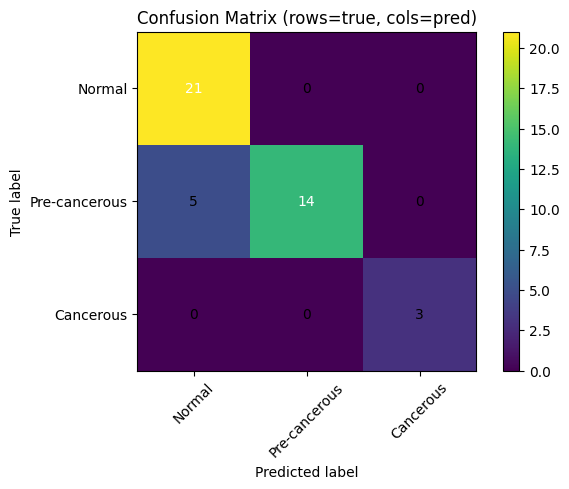

In [23]:
# Cell 10: Final TEST evaluation + Confusion Matrix PLOT + Sensitivity & Specificity

@torch.no_grad()
def evaluate_with_report(model, loader, criterion, device, idx_to_class, num_classes=3):
    stats = evaluate(model, loader, criterion, device, num_classes=num_classes)
    cm = stats["cm"].cpu().numpy()
    perclass = per_class_prf1(torch.tensor(cm))

    print("\n=== Test Results ===")
    print(f"Loss: {stats['loss']:.4f}  Acc: {stats['acc']:.4f}  Macro-F1: {stats['macro_f1']:.4f}\n")

    # ---- compute sensitivity & specificity ----
    total = cm.sum()
    sens_list, spec_list = [], []
    print("Per-class metrics:")
    for i, cls_name in enumerate([idx_to_class[c] for c in range(num_classes)]):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - (TP + FP + FN)
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # same as recall
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

        sens_list.append(sensitivity)
        spec_list.append(specificity)

        prec = perclass[i]["precision"]
        rec  = perclass[i]["recall"]
        f1   = perclass[i]["f1"]
        support = perclass[i]["support"]

        print(f"  {i} ({cls_name}): "
              f"precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}  "
              f"sensitivity={sensitivity:.3f}  specificity={specificity:.3f}  support={support}")

    macro_sens = np.mean(sens_list)
    macro_spec = np.mean(spec_list)
    print(f"\nMacro-avg Sensitivity: {macro_sens:.3f}  Specificity: {macro_spec:.3f}")

    # ---- plot confusion matrix ----
    plot_confusion_matrix(cm, [idx_to_class[i] for i in range(num_classes)])

if test_loader is not None:
    evaluate_with_report(model, test_loader, criterion, dev, idx_to_class, num_classes=3)
else:
    print("No test set configured.")

